# Proyek Klasifikasi Gambar: Flower Image Classification
- **Nama:** `Shendi Teuku Maulana Efendi`
- **Email:** `shendyteuku2@gmail.com`
- **ID Dicoding:** `shendyeff`

## Import Semua Packages/Library yang Digunakan

In [2]:
!pip uninstall tensorflowjs
!pip install tensorflowjs

Found existing installation: tensorflowjs 4.22.0
Uninstalling tensorflowjs-4.22.0:
  Would remove:
    /usr/local/bin/tensorflowjs_converter
    /usr/local/bin/tensorflowjs_wizard
    /usr/local/lib/python3.11/dist-packages/tensorflowjs-4.22.0.dist-info/*
    /usr/local/lib/python3.11/dist-packages/tensorflowjs/*
Proceed (Y/n)? y
  Successfully uninstalled tensorflowjs-4.22.0
  Using cached tensorflowjs-4.22.0-py3-none-any.whl.metadata (3.2 kB)
Using cached tensorflowjs-4.22.0-py3-none-any.whl (89 kB)


In [54]:
import os
import random
import shutil
import pathlib
import glob
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import cv2
import gdown
import absl.logging
import logging

warnings.filterwarnings('ignore')

import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dropout, Dense,
    GlobalAveragePooling2D, BatchNormalization
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0, MobileNetV2
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [5]:
print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.19.0


In [6]:
print(f'TensorFlow.js version: {tfjs.__version__}')

TensorFlow.js version: 4.22.0


## Data Preparation

`Link Dataset!` <br>
[![Google Drive Dataset](https://img.shields.io/badge/Download%20Dataset-Google%20Drive-blue?style=for-the-badge&logo=google-drive)](https://drive.google.com/file/d/1m9UBYCzLElZ8x_-b_jysE7A9y-jSq04u/view?usp=drive_link)

### Data Loading

In [7]:
file_id = '1m9UBYCzLElZ8x_-b_jysE7A9y-jSq04u'

url = f'https://drive.google.com/uc?id={file_id}'
output = '/content/dataset-flowers.zip'

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1m9UBYCzLElZ8x_-b_jysE7A9y-jSq04u
From (redirected): https://drive.google.com/uc?id=1m9UBYCzLElZ8x_-b_jysE7A9y-jSq04u&confirm=t&uuid=b921aa4a-e54e-479d-b1a3-0e060ca67c52
To: /content/dataset-flowers.zip
100%|██████████| 215M/215M [00:04<00:00, 50.5MB/s]


'/content/dataset-flowers.zip'

#### Unzip Dataset

In [8]:
!unzip dataset-flowers.zip -d dataset-flowers/

Streaming output truncated to the last 5000 lines.
  inflating: dataset-flowers/train/iris/17858672081_4b4d071116_c.jpg  
  inflating: dataset-flowers/train/iris/17885928250_451875aec2_c.jpg  
  inflating: dataset-flowers/train/iris/17948299355_2161a031db_c.jpg  
  inflating: dataset-flowers/train/iris/17959086836_3e706d918b_c.jpg  
  inflating: dataset-flowers/train/iris/18054931376_23052f68d0_c.jpg  
  inflating: dataset-flowers/train/iris/18059533553_186ccb451a_c.jpg  
  inflating: dataset-flowers/train/iris/18076633321_400ea17b5a_c.jpg  
  inflating: dataset-flowers/train/iris/18120244292_ea11fcc9c5_c.jpg  
  inflating: dataset-flowers/train/iris/181379030_afebe26851_c.jpg  
  inflating: dataset-flowers/train/iris/18141122602_118114762d_c.jpg  
  inflating: dataset-flowers/train/iris/18256508742_af6a8f4222_c.jpg  
  inflating: dataset-flowers/train/iris/18280071332_c6bc90d75a_c.jpg  
  inflating: dataset-flowers/train/iris/18348714266_33a7bf205f_c.jpg  
  inflating: dataset-flowers

In [9]:
remove_file = '/content/dataset-flowers.zip'
os.remove(remove_file)

#### Cek Keberagaman Resolusi Dataset

In [10]:
def count_images_and_resolution(base_path, target_resolution=None):
    # Dictionary untuk menyimpan jumlah gambar per kelas
    class_count = {}

    # Dictionary untuk menyimpan jumlah gambar per resolusi
    resolution_count = {}

    for root, dirs, files in os.walk(base_path):
        # Mengabaikan folder root yang tidak memiliki gambar
        if root == base_path:
            continue
        class_name = os.path.basename(root)
        class_count[class_name] = len(files)

        for file in files:
            file_path = os.path.join(root, file)
            # Check if the file is an image file
            if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                continue # Skip if not an image file
            with Image.open(file_path) as img:
                width, height = img.size
                resolution = f"{width}x{height}"
                if resolution not in resolution_count:
                    resolution_count[resolution] = 0
                resolution_count[resolution] += 1

                # Menghitung jumlah gambar dengan resolusi target_resolution
                if target_resolution and resolution == target_resolution:
                    if 'target' not in resolution_count:
                        resolution_count['target'] = 0
                    resolution_count['target'] += 1

    return class_count, resolution_count

base_path = "/content/dataset-flowers"
target_resolution = "256x256"

class_count, resolution_count = count_images_and_resolution(base_path, target_resolution)

In [11]:
print("Jumlah gambar per kelas:")
for class_name, count in class_count.items():
    print(f"{class_name}: {count}")

print("\nJumlah gambar per resolusi:")
for resolution, count in resolution_count.items():
    print(f"{resolution}: {count}")

Jumlah gambar per kelas:
val: 1
carnation: 924
black_eyed_susan: 986
water_lily: 977
iris: 1041
bellflower: 872
tulip: 1034
california_poppy: 1021
dandelion: 1038
common_daisy: 978
astilbe: 726
calendula: 1011
rose: 986
coreopsis: 1035
sunflower: 1013
train: 1

Jumlah gambar per resolusi:
256x256: 12756
target: 12756
800x600: 76
695x800: 1
799x525: 1
800x534: 52
799x526: 1
799x500: 1
799x534: 23
800x587: 1
799x533: 238
595x800: 1
800x493: 1
800x572: 5
533x799: 22
800x660: 1
800x513: 2
800x222: 1
800x800: 50
800x717: 3
800x501: 2
800x450: 23
800x777: 1
800x599: 3
800x640: 15
799x521: 1
799x554: 1
799x546: 3
799x569: 1
800x530: 14
799x532: 5
800x533: 27
800x542: 2
800x573: 1
799x571: 30
799x794: 1
800x451: 3
800x740: 1
799x540: 2
799x239: 1
800x523: 2
800x705: 2
596x799: 1
800x508: 1
600x800: 8
800x563: 3
800x539: 2
799x550: 1
800x595: 4
799x484: 1
800x603: 3
800x557: 4
800x612: 2
800x525: 3
799x800: 6
800x449: 7
800x639: 2
534x800: 10
531x800: 2
535x800: 2
800x549: 2
799x768: 1
498x768:

#### Mengecek Daftar Label Kelas
Untuk sekarang dataset masih terbagi menjadi `train` dan `val`, dimana nanti dilakukan penyesuaian dataset pada tahap splitting yaitu menjadi `train`, `valid`, dan `test`

In [12]:
image_data='/content/dataset-flowers/train'
pd.DataFrame(os.listdir(image_data),columns=['Files_Name'])

,Files_Name
0,carnation
1,black_eyed_susan
2,water_lily
3,iris
4,bellflower
5,tulip
6,california_poppy
7,dandelion
8,common_daisy
9,astilbe


In [13]:
image_test_data='/content/dataset-flowers/val'
pd.DataFrame(os.listdir(image_test_data),columns=['Files_Name'])

,Files_Name
0,carnation
1,black_eyed_susan
2,water_lily
3,iris
4,bellflower
5,tulip
6,california_poppy
7,dandelion
8,common_daisy
9,astilbe


In [14]:
files = [i for i in glob.glob(image_data + "//*//*")]
np.random.shuffle(files)
labels = [os.path.dirname(i).split("/")[-1] for i in files]
data = zip(files, labels)
dataframe = pd.DataFrame(data, columns = ["Image", "Label"])
dataframe

,Image,Label
0,/content/dataset-flowers/train/rose/2211941634...,rose
1,/content/dataset-flowers/train/tulip/333765664...,tulip
2,/content/dataset-flowers/train/water_lily/7427...,water_lily
3,/content/dataset-flowers/train/sunflower/37125...,sunflower
4,/content/dataset-flowers/train/calendula/12232...,calendula
...,...,...
13637,/content/dataset-flowers/train/sunflower/15352...,sunflower
13638,/content/dataset-flowers/train/rose/4103620810...,rose
13639,/content/dataset-flowers/train/california_popp...,california_poppy
13640,/content/dataset-flowers/train/tulip/335965843...,tulip


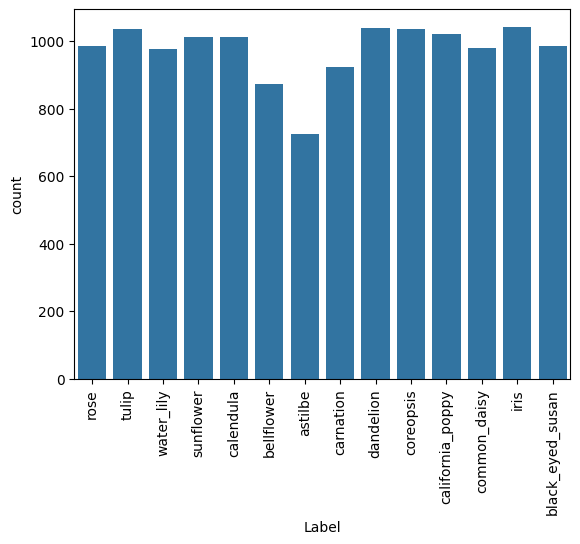

In [15]:
sns.countplot(x = dataframe["Label"])
plt.xticks(rotation = 90);

### Data Preprocessing

#### Split Dataset

In [22]:
# Path asal
base_dir = 'dataset-flowers'
combined_dir = 'combined_dataset'

# Gabungkan semua gambar dari train dan val ke satu folder sementara
if not os.path.exists(combined_dir):
    os.makedirs(combined_dir)

    for folder in ['train', 'val']:
        folder_path = os.path.join(base_dir, folder)
        for class_name in os.listdir(folder_path):
            class_path = os.path.join(folder_path, class_name)

            # ⛔ Skip kalau bukan folder
            if not os.path.isdir(class_path):
                continue

            dest_class_path = os.path.join(combined_dir, class_name)
            os.makedirs(dest_class_path, exist_ok=True)

            for img_file in os.listdir(class_path):
                src = os.path.join(class_path, img_file)
                dst = os.path.join(dest_class_path, img_file)
                shutil.copy2(src, dst)

# Bikin folder baru buat split ulang
split_base = 'dataset_split'
for split in ['train', 'val', 'test']:
    for class_name in os.listdir(combined_dir):
        os.makedirs(os.path.join(split_base, split, class_name), exist_ok=True)

# Parameter split
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Split dan salin file
for class_name in os.listdir(combined_dir):
    class_dir = os.path.join(combined_dir, class_name)

    if not os.path.isdir(class_dir):
        continue

    images = os.listdir(class_dir)
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy2(os.path.join(class_dir, img), os.path.join(split_base, 'train', class_name, img))
    for img in val_imgs:
        shutil.copy2(os.path.join(class_dir, img), os.path.join(split_base, 'val', class_name, img))
    for img in test_imgs:
        shutil.copy2(os.path.join(class_dir, img), os.path.join(split_base, 'test', class_name, img))

print("Dataset successfully re-split into train, val, and test.")

Dataset successfully re-split into train, val, and test.


#### Load Train, Validation, dan Test Set dari Folder Split

In [23]:
base_dir = 'dataset_split'
batch_size = 32
target_size = (224, 224)

# Load train dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory=os.path.join(base_dir, 'train'),
    label_mode='categorical',  # pakai categorical kalau multi-class
    image_size=target_size,
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

# Load validation dataset
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory=os.path.join(base_dir, 'val'),
    label_mode='categorical',
    image_size=target_size,
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

# Load test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory=os.path.join(base_dir, 'test'),
    label_mode='categorical',
    image_size=target_size,
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

Found 13363 files belonging to 14 classes.
Found 5336 files belonging to 14 classes.
Found 5345 files belonging to 14 classes.


In [24]:
class_names = train_dataset.class_names
class_names

['astilbe',
 'bellflower',
 'black_eyed_susan',
 'calendula',
 'california_poppy',
 'carnation',
 'common_daisy',
 'coreopsis',
 'dandelion',
 'iris',
 'rose',
 'sunflower',
 'tulip',
 'water_lily']

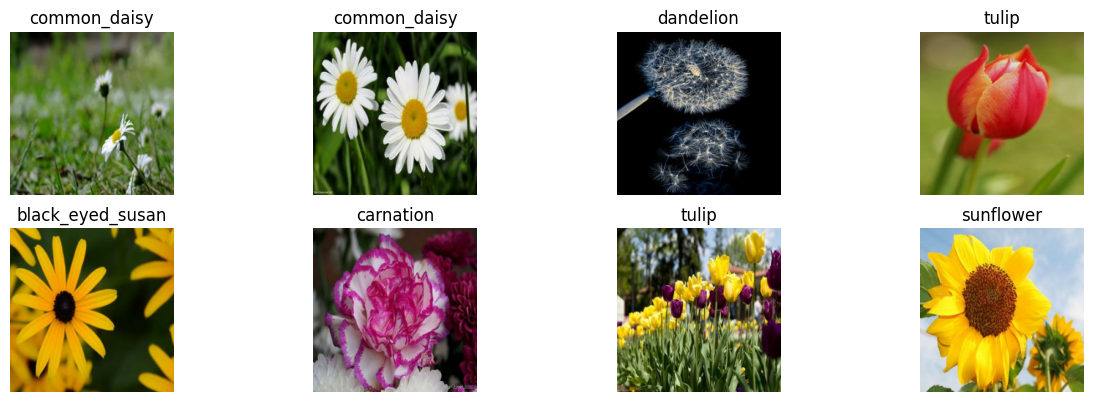

In [25]:
plt.figure(figsize=(15, 20))
for images, labels in train_dataset.take(1):
    for i in range(8):
        ax = plt.subplot(8, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class_index = np.argmax(labels[i].numpy())

        plt.title(class_names[predicted_class_index])
        plt.axis("off")

## Modelling

In [26]:
base_model = tf.keras.applications.MobileNetV3Large(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

keras_model = tf.keras.models.Sequential()

# Add Input layer
keras_model.add(tf.keras.Input(shape=(224,224,3)))

# Add base model (MobileNetV3Large)
keras_model.add(base_model)

# Add custom layers: Conv2D and MaxPooling2D
keras_model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu',padding='same'))  # 64 filters, 3x3 kernel, add padding
keras_model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))         # Max Pooling with 2x2 pool size

keras_model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu',padding='same')) # 128 filters, 3x3 kernel, add padding
keras_model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))         # Max Pooling with 2x2 pool size

# Flatten and add Dense layers
keras_model.add(tf.keras.layers.Flatten())
keras_model.add(tf.keras.layers.Dropout(0.5))
keras_model.add(tf.keras.layers.Dense(14, activation=tf.nn.softmax))

# Print model summary
keras_model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)        │ (None, 7, 7, 960)           │       2,996,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 7, 64)            │         553,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 14)                  │           1,806 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,625,038 (13.83 MB)

 Trainable params: 628,686 (2.40 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

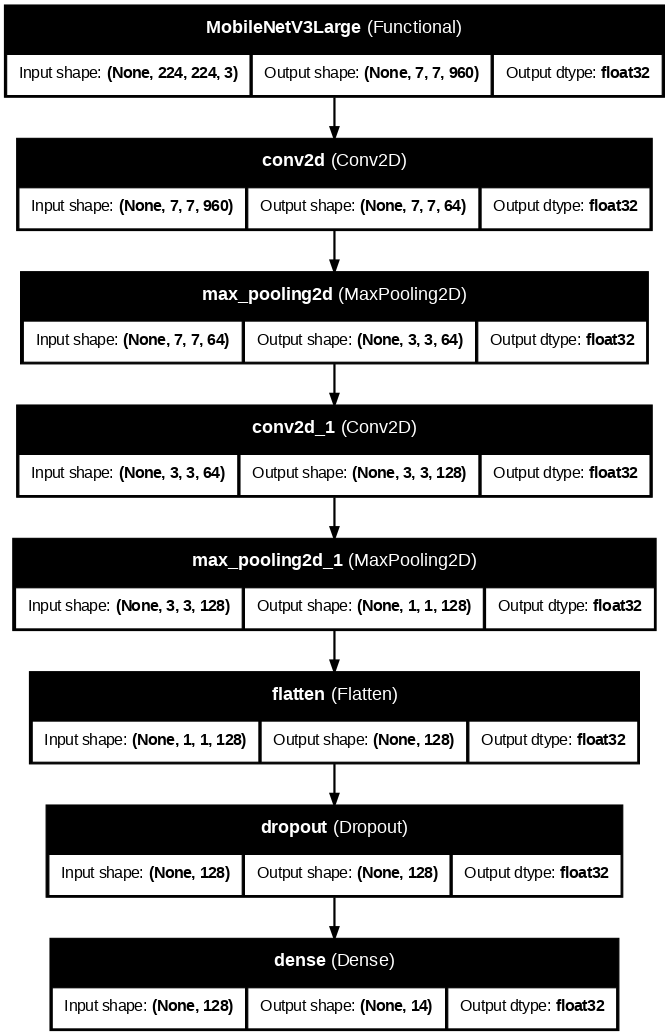

In [27]:
tf.keras.utils.plot_model(keras_model, to_file='model.png', show_shapes=True, show_layer_names=True,show_dtype=True,dpi=80)

### Implementasi Callback

In [28]:
checkpoint = ModelCheckpoint("my_keras_model.keras", save_best_only=True)
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

keras_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model

In [29]:
hist = keras_model.fit(
    train_dataset,
    epochs=40,
    validation_data=val_dataset,  # pakai val_dataset, bukan validation dari split
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 59s 105ms/step - accuracy: 0.6352 - loss: 1.3132 - val_accuracy: 0.9267 - val_loss: 0.2364
Epoch 2/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 49s 48ms/step - accuracy: 0.8983 - loss: 0.3423 - val_accuracy: 0.9578 - val_loss: 0.1328
Epoch 3/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9225 - loss: 0.2568 - val_accuracy: 0.9642 - val_loss: 0.1099
Epoch 4/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9465 - loss: 0.1880 - val_accuracy: 0.9805 - val_loss: 0.0711
Epoch 5/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9601 - loss: 0.1340 - val_accuracy: 0.9768 - val_loss: 0.0822
Epoch 6/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.9657 - loss: 0.1098 - val_accuracy: 0.9854 - val_loss: 0.0598
Epoch 7/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9722 - loss: 0.0905 - val_accuracy: 0.9799 - val_loss: 0.0814
Epoch 8/40
418/418 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9746 - loss: 0.0808 -

In [30]:
hist_=pd.DataFrame(hist.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.771084,0.774261,0.926724,0.236384
1,0.908628,0.312965,0.957834,0.132810
2,0.930106,0.231330,0.964205,0.109909
3,0.950760,0.169003,0.980510,0.071104
4,0.963332,0.121680,0.976762,0.082159
5,0.969842,0.103231,0.985382,0.059826
6,0.971788,0.096051,0.979948,0.081450
7,0.972012,0.089362,0.980322,0.079303
8,0.975604,0.097226,0.971889,0.127668
9,0.979271,0.073268,0.990067,0.043219


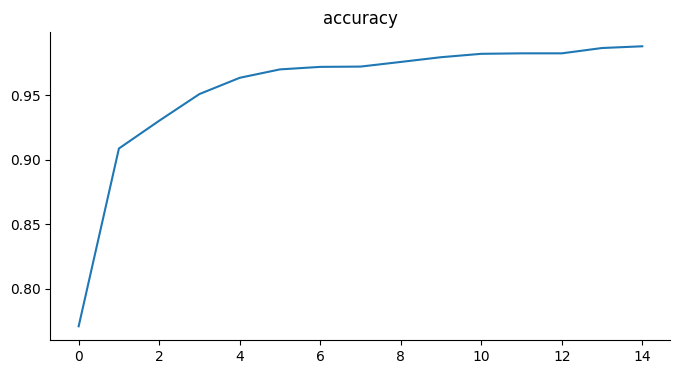

In [31]:
hist_['accuracy'].plot(kind='line', figsize=(8, 4), title='accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

## Evaluasi dan Visualisasi

In [32]:
score, acc = keras_model.evaluate(val_dataset)
print('Test Loss =', score)
print('Test Accuracy =', acc)

167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9888 - loss: 0.0468
Test Loss = 0.04321850836277008
Test Accuracy = 0.9900674819946289


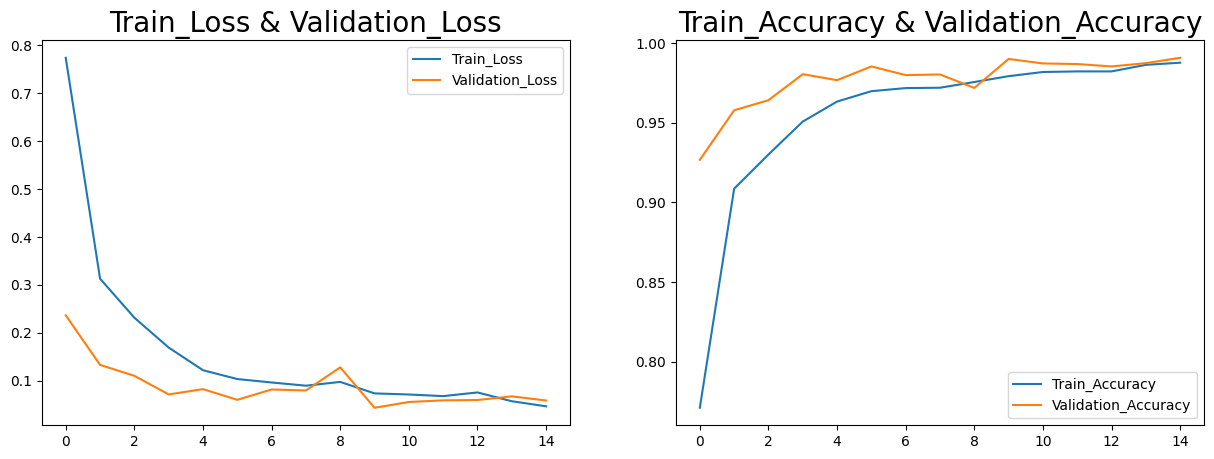

In [33]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()

## Konversi Model

Konversi model menjadi format `saved_model`

In [40]:
keras_model.export("saved_model/my_model")

Saved artifact at 'saved_model/my_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_203')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  137977861950160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977809573584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977809573392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977861950352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977861948816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977809568208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977809574352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977809573968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977861949008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137977809574544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13797

Konversi model menjadi format `TF Lite`

In [42]:
# 1. Konversi SavedModel ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model/my_model")
tflite_model = converter.convert()

# 2. Buat folder simpan model TFLite
os.makedirs('tflite', exist_ok=True)

# 3. Simpan model .tflite
with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model berhasil dikonversi ke TFLite dan disimpan sebagai 'tflite/model.tflite'")

# 4. Simpan file label (klasifikasi 14 jenis bunga)
class_names = [
    'astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy',
    'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris',
    'rose', 'sunflower', 'tulip', 'water_lily'
]

with open('tflite/label.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')

print("Label berhasil disimpan sebagai 'tflite/label.txt'")

Model berhasil dikonversi ke TFLite dan disimpan sebagai 'tflite/model.tflite'
Label berhasil disimpan sebagai 'tflite/label.txt'


Konversi model menjadi format `TFJS`

In [43]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    saved_model/my_model \
    tfjs_model

2025-04-10 09:50:34.728429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744278634.749754    8794 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744278634.756854    8794 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744278634.773706    8794 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744278634.773735    8794 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744278634.773739    8794 computation_placer.cc:177] computation placer alr

Menyimpan dependencies yang digunakan pada project

In [44]:
!pip freeze > requirements.txt

## Inference (Optional)

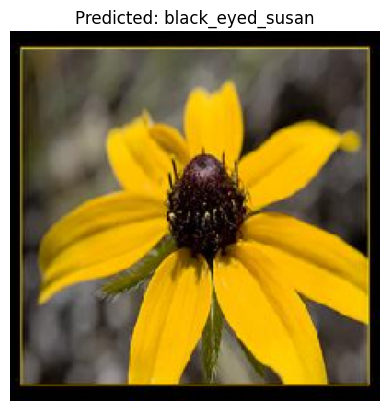

In [58]:
# Load the TFLite model using tf.lite.Interpreter
interpreter = tf.lite.Interpreter(model_path='tflite/model.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Path gambar yang di-upload
img_path = "/content/dataset_split/test/black_eyed_susan/1057222299_1389a4723e_c.jpg"  # Nama file yang di-upload

# Load dan preprocess gambar yang di-upload
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Set input tensor and invoke the interpreter
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

# Get the output tensor
predictions = interpreter.get_tensor(output_details[0]['index'])

# Get predicted class
predicted_class = np.argmax(predictions, axis=1)

predicted_label = class_names[predicted_class[0]]

# Display the image and prediction
plt.imshow(img)
plt.title(f'Predicted: {predicted_label}')
plt.axis('off')
plt.show()

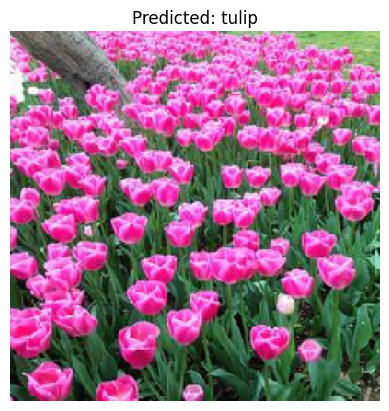

In [59]:
# Load the TFLite model using tf.lite.Interpreter
interpreter = tf.lite.Interpreter(model_path='tflite/model.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Path gambar yang di-upload
img_path = "/content/dataset_split/test/tulip/10400415455_7a4796d598_c.jpg"  # Nama file yang di-upload

# Load dan preprocess gambar yang di-upload
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Set input tensor and invoke the interpreter
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

# Get the output tensor
predictions = interpreter.get_tensor(output_details[0]['index'])

# Get predicted class
predicted_class = np.argmax(predictions, axis=1)

predicted_label = class_names[predicted_class[0]]

# Display the image and prediction
plt.imshow(img)
plt.title(f'Predicted: {predicted_label}')
plt.axis('off')
plt.show()

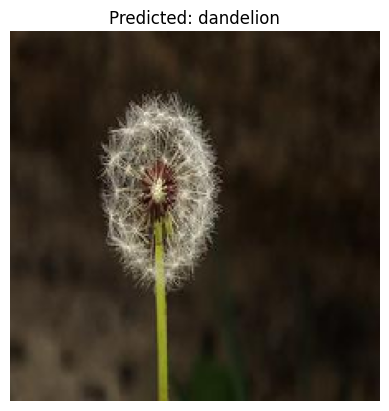

In [60]:
# Load the TFLite model using tf.lite.Interpreter
interpreter = tf.lite.Interpreter(model_path='tflite/model.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Path gambar yang di-upload
img_path = "/content/dataset_split/test/dandelion/10774849493_bb82957f1b_c.jpg"  # Nama file yang di-upload

# Load dan preprocess gambar yang di-upload
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Set input tensor and invoke the interpreter
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

# Get the output tensor
predictions = interpreter.get_tensor(output_details[0]['index'])

# Get predicted class
predicted_class = np.argmax(predictions, axis=1)

predicted_label = class_names[predicted_class[0]]

# Display the image and prediction
plt.imshow(img)
plt.title(f'Predicted: {predicted_label}')
plt.axis('off')
plt.show()

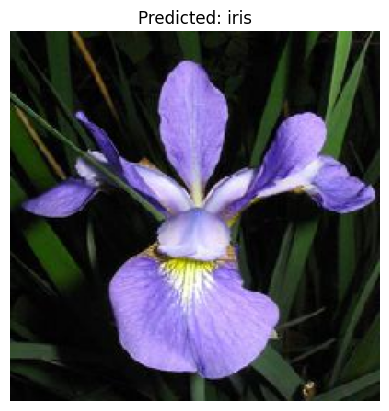

In [61]:
# Load the TFLite model using tf.lite.Interpreter
interpreter = tf.lite.Interpreter(model_path='tflite/model.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Path gambar yang di-upload
img_path = "/content/dataset_split/test/iris/164507281_f5c9796e11_c.jpg"  # Nama file yang di-upload

# Load dan preprocess gambar yang di-upload
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Set input tensor and invoke the interpreter
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

# Get the output tensor
predictions = interpreter.get_tensor(output_details[0]['index'])

# Get predicted class
predicted_class = np.argmax(predictions, axis=1)

predicted_label = class_names[predicted_class[0]]

# Display the image and prediction
plt.imshow(img)
plt.title(f'Predicted: {predicted_label}')
plt.axis('off')
plt.show()